# 02 · Real 400×160×731 input and event evolution
This notebook reruns the full three-dimensional overlap tracker and visualizes occurrence frequency, daily activity, event duration, and one real event's evolution.
The input directory defaults to the package root, `/Volumes/new_drive/lagrangian/julia`, which also contains the user-provided MATLAB data. Set `MHW_DATA_DIR` or edit `DATA_DIR` to use another location. No calendar dates were supplied, so time axes use one-based day indices.

In [1]:
include(isfile("bootstrap.jl") ? "bootstrap.jl" : "notebooks/bootstrap.jl")
DATA_DIR=get(ENV,"MHW_DATA_DIR",ROOT)
isfile(joinpath(DATA_DIR,"mhw_ts.mat")) || error("Set MHW_DATA_DIR to the provided data directory")

  Activating 

Julia 1

project at `/Volumes/new_drive/lagrangian/julia/notebooks`


.12.3 | MHWTracking 0.1.0


true

## Inspect the original array and binarize explicitly
No dimensions are permuted. Only `isfinite(value) && value > 0` indicates an event; negative values, NaN, Inf, and zero are excluded.

In [2]:
raw=load_test_data(DATA_DIR;binary_rule=:raw)
mask=isfinite.(raw.mask).&(raw.mask.>0)
lon,lat=raw.lon,raw.lat
println("Input shape: ",size(raw.mask)," | datatype: ",eltype(raw.mask))
println("NaNs: ",count(isnan,raw.mask)," | positive finite: ",count(mask))
@test size(mask)==(400,160,731)
@test count(mask)==1_823_266
raw=nothing # release the 374 MB raw numeric field before plotting
GC.gc()

Input shape: (

400, 160, 731) | datatype: Float64
NaNs: 44960259 | positive finite: 1823266


## Run the full tracker
Warm up on an independent small array before measuring tracker execution time and cumulative allocations. Plotting, file loading, and MATLAB comparisons are excluded from this timer.

In [3]:
track_mhw_3d(mask[1:10,1:10,1:6],lon[1:10],lat[1:10],4)
GC.gc()
measurement=@timed track_mhw_3d(mask,lon,lat,4)
tracks=measurement.value
println("Tracks: ",length(tracks)," | seconds: ",measurement.time,
        " | cumulative allocation GiB: ",measurement.bytes/2.0^30)
@test length(tracks)==4277

Tracks: 4277

 | seconds: 3.09844925 | cumulative allocation GiB: 2.9867749512195587


Test Passed

## Spatial occurrence frequency and daily active cells
The left panel shows the fraction of all 731 days identified as MHW, which differs from occupancy by retained tracks. The right panel shows active input cells on each day.
Each grid cell has equal weight; no area weighting is applied. Longitude and latitude use the actual geographic coordinates.

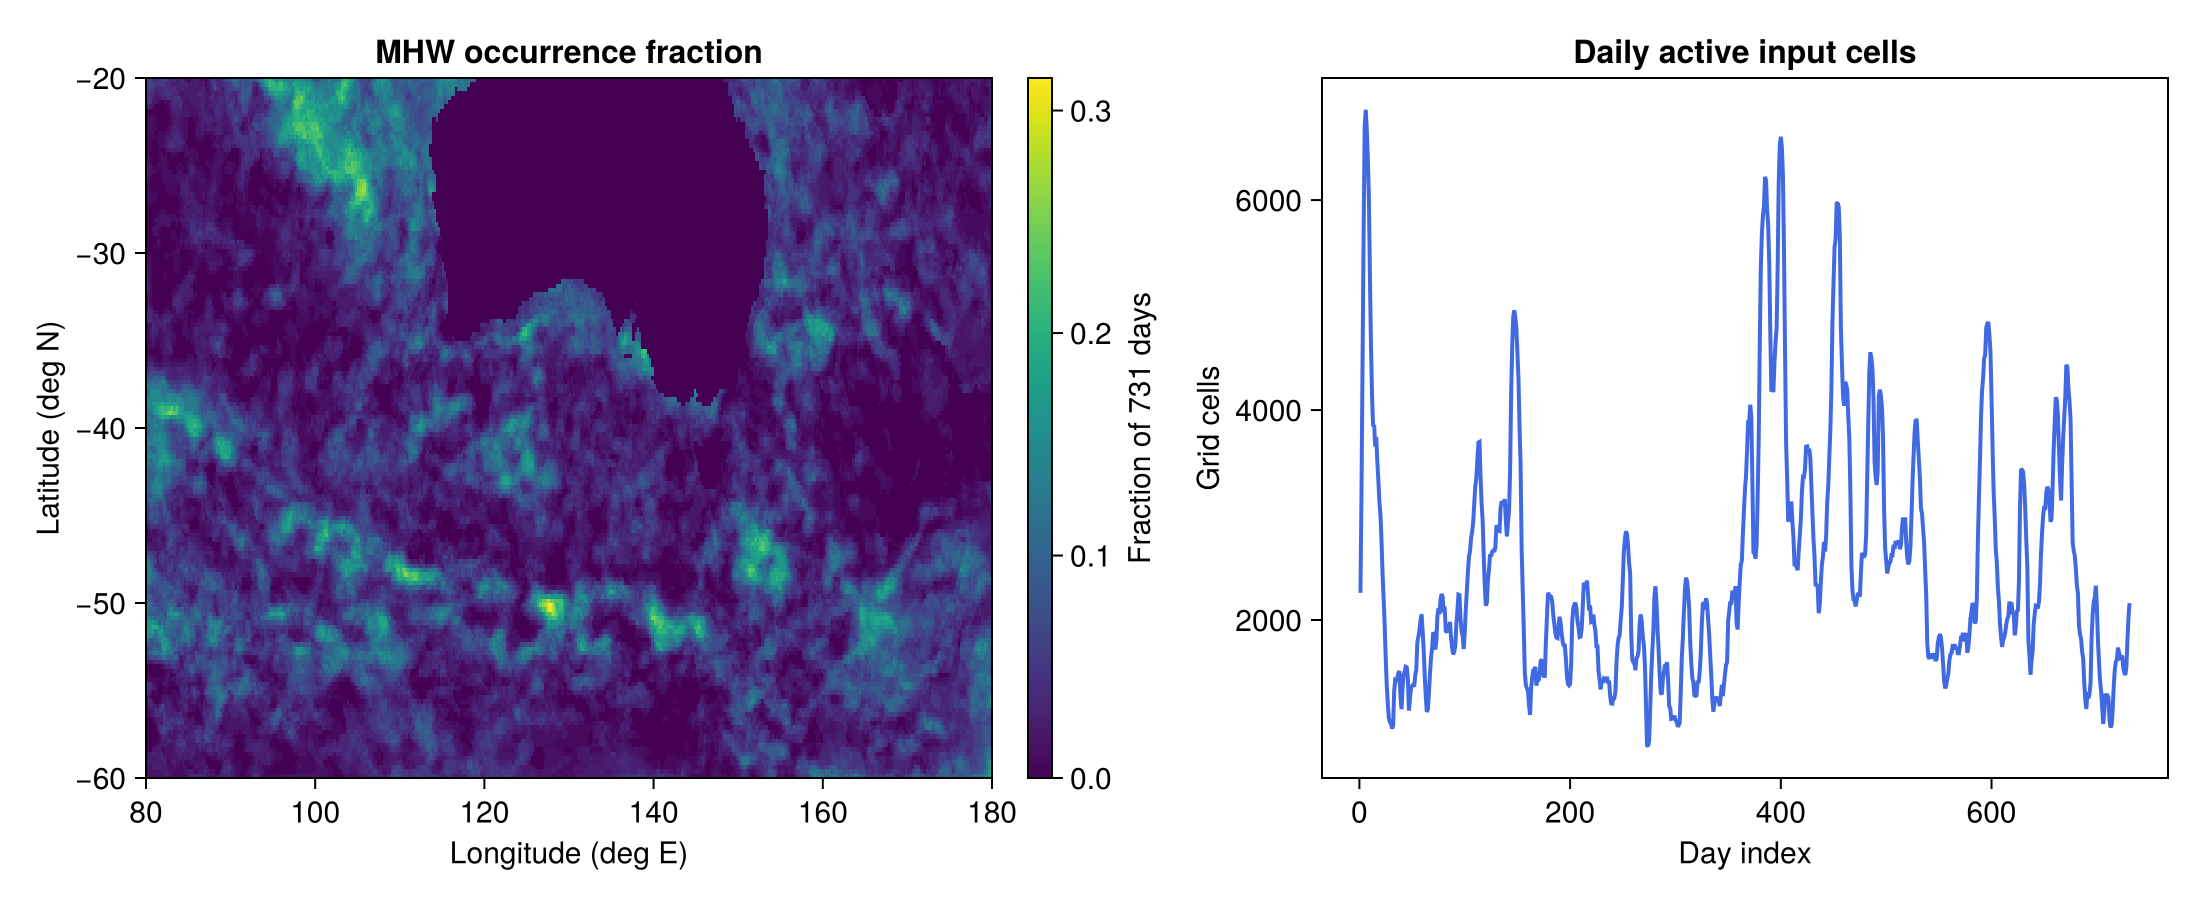

In [4]:
frequency=dropdims(sum(mask;dims=3);dims=3)./size(mask,3)
daily=[count(@view mask[:,:,day]) for day in axes(mask,3)]
fig=Figure(size=(1100,450))
ax=Axis(fig[1,1],title="MHW occurrence fraction",xlabel="Longitude (deg E)",ylabel="Latitude (deg N)")
hm=heatmap!(ax,lon,lat,frequency;colormap=:viridis,colorrange=(0,maximum(frequency)))
Colorbar(fig[1,2],hm,label="Fraction of 731 days")
ax2=Axis(fig[1,3],title="Daily active input cells",xlabel="Day index",ylabel="Grid cells")
lines!(ax2,1:length(daily),daily,color=:royalblue,linewidth=2)
emit_figure(fig,"02_real_occurrence")

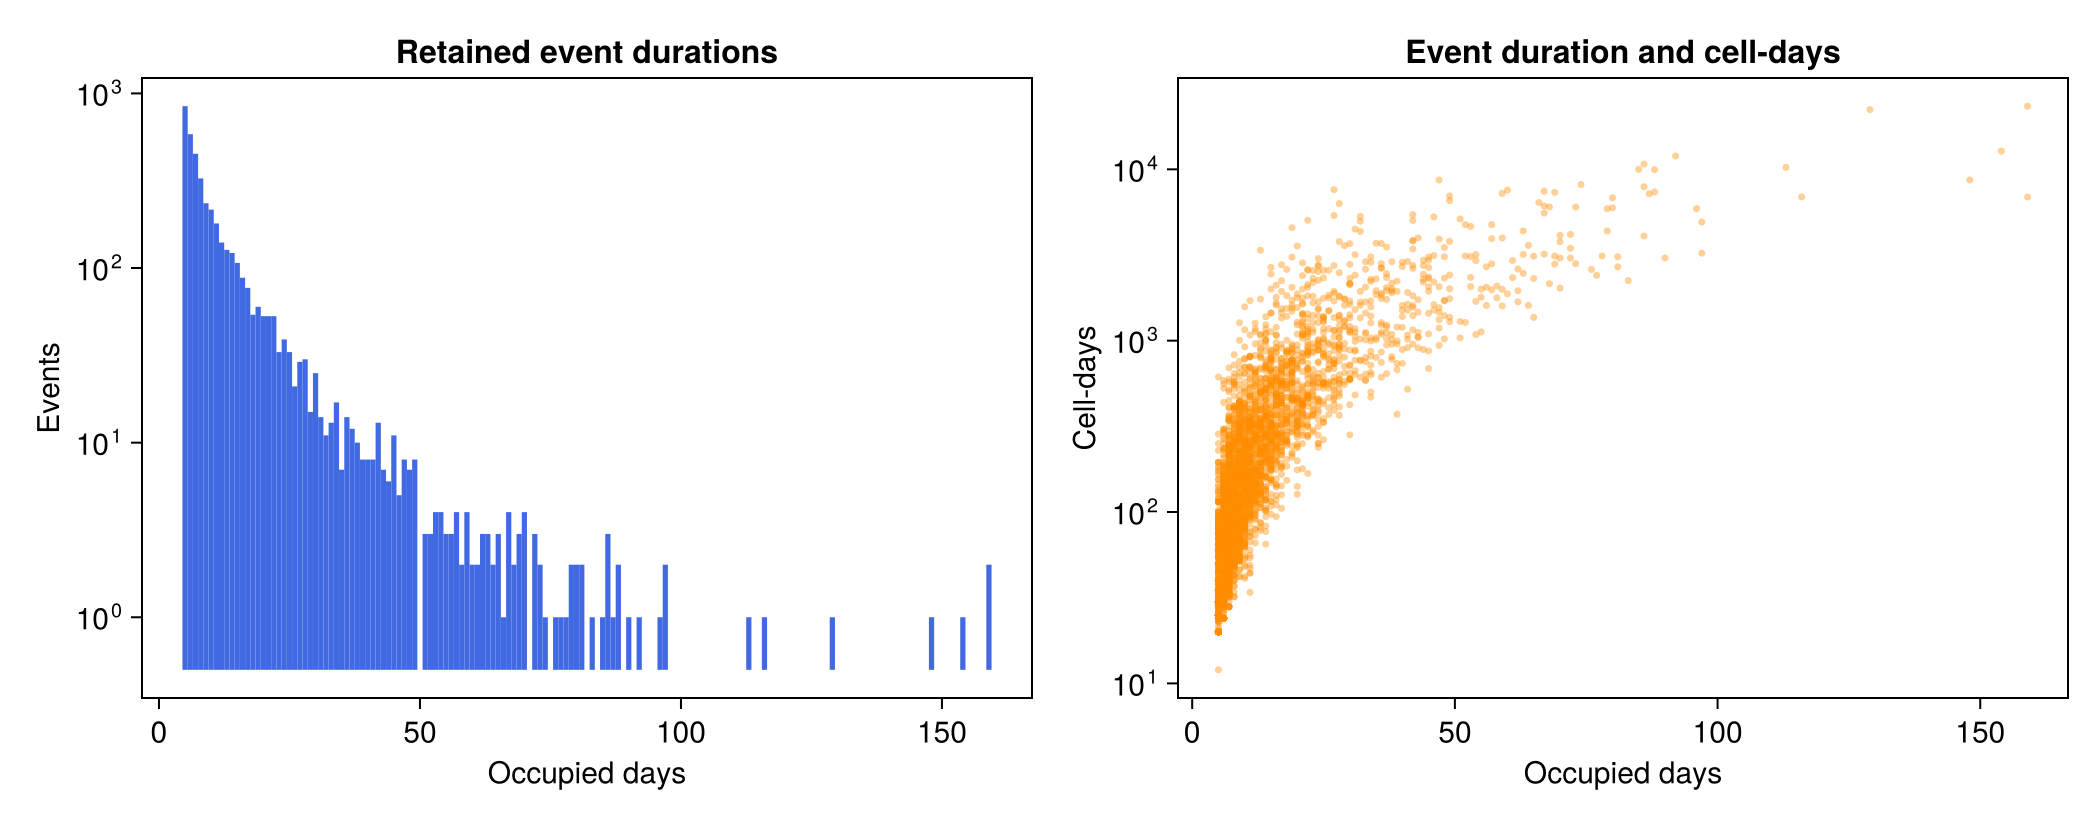

In [5]:
duration=length.(getproperty.(tracks,:day))
coverage=[sum(length,t.xloc) for t in tracks]
fig=Figure(size=(1050,410))
ax=Axis(fig[1,1],title="Retained event durations",xlabel="Occupied days",ylabel="Events",yscale=log10)
hist!(ax,duration;bins=collect(4.5:1:maximum(duration)+0.5),color=:royalblue)
ax2=Axis(fig[1,2],title="Event duration and cell-days",xlabel="Occupied days",ylabel="Cell-days",yscale=log10)
scatter!(ax2,duration,coverage;markersize=5,color=(:darkorange,0.4))
emit_figure(fig,"02_real_event_statistics")

## Spatial evolution and daily size of a real event
Select deterministically the event with the largest cumulative cell-days among those lasting 7–30 days; change `event_id` to inspect another event. The background shows that day's input MHW cells, and red points identify the selected event.
The original algorithm connects the first and last longitude cells even for this 80–180°E region. This behavior merits attention in a scientific application and is retained here to match the MATLAB source.

Event #2204 | days 379–405 | cell-days 7607 | split days 

[397, 399, 400, 401, 402, 403, 404]


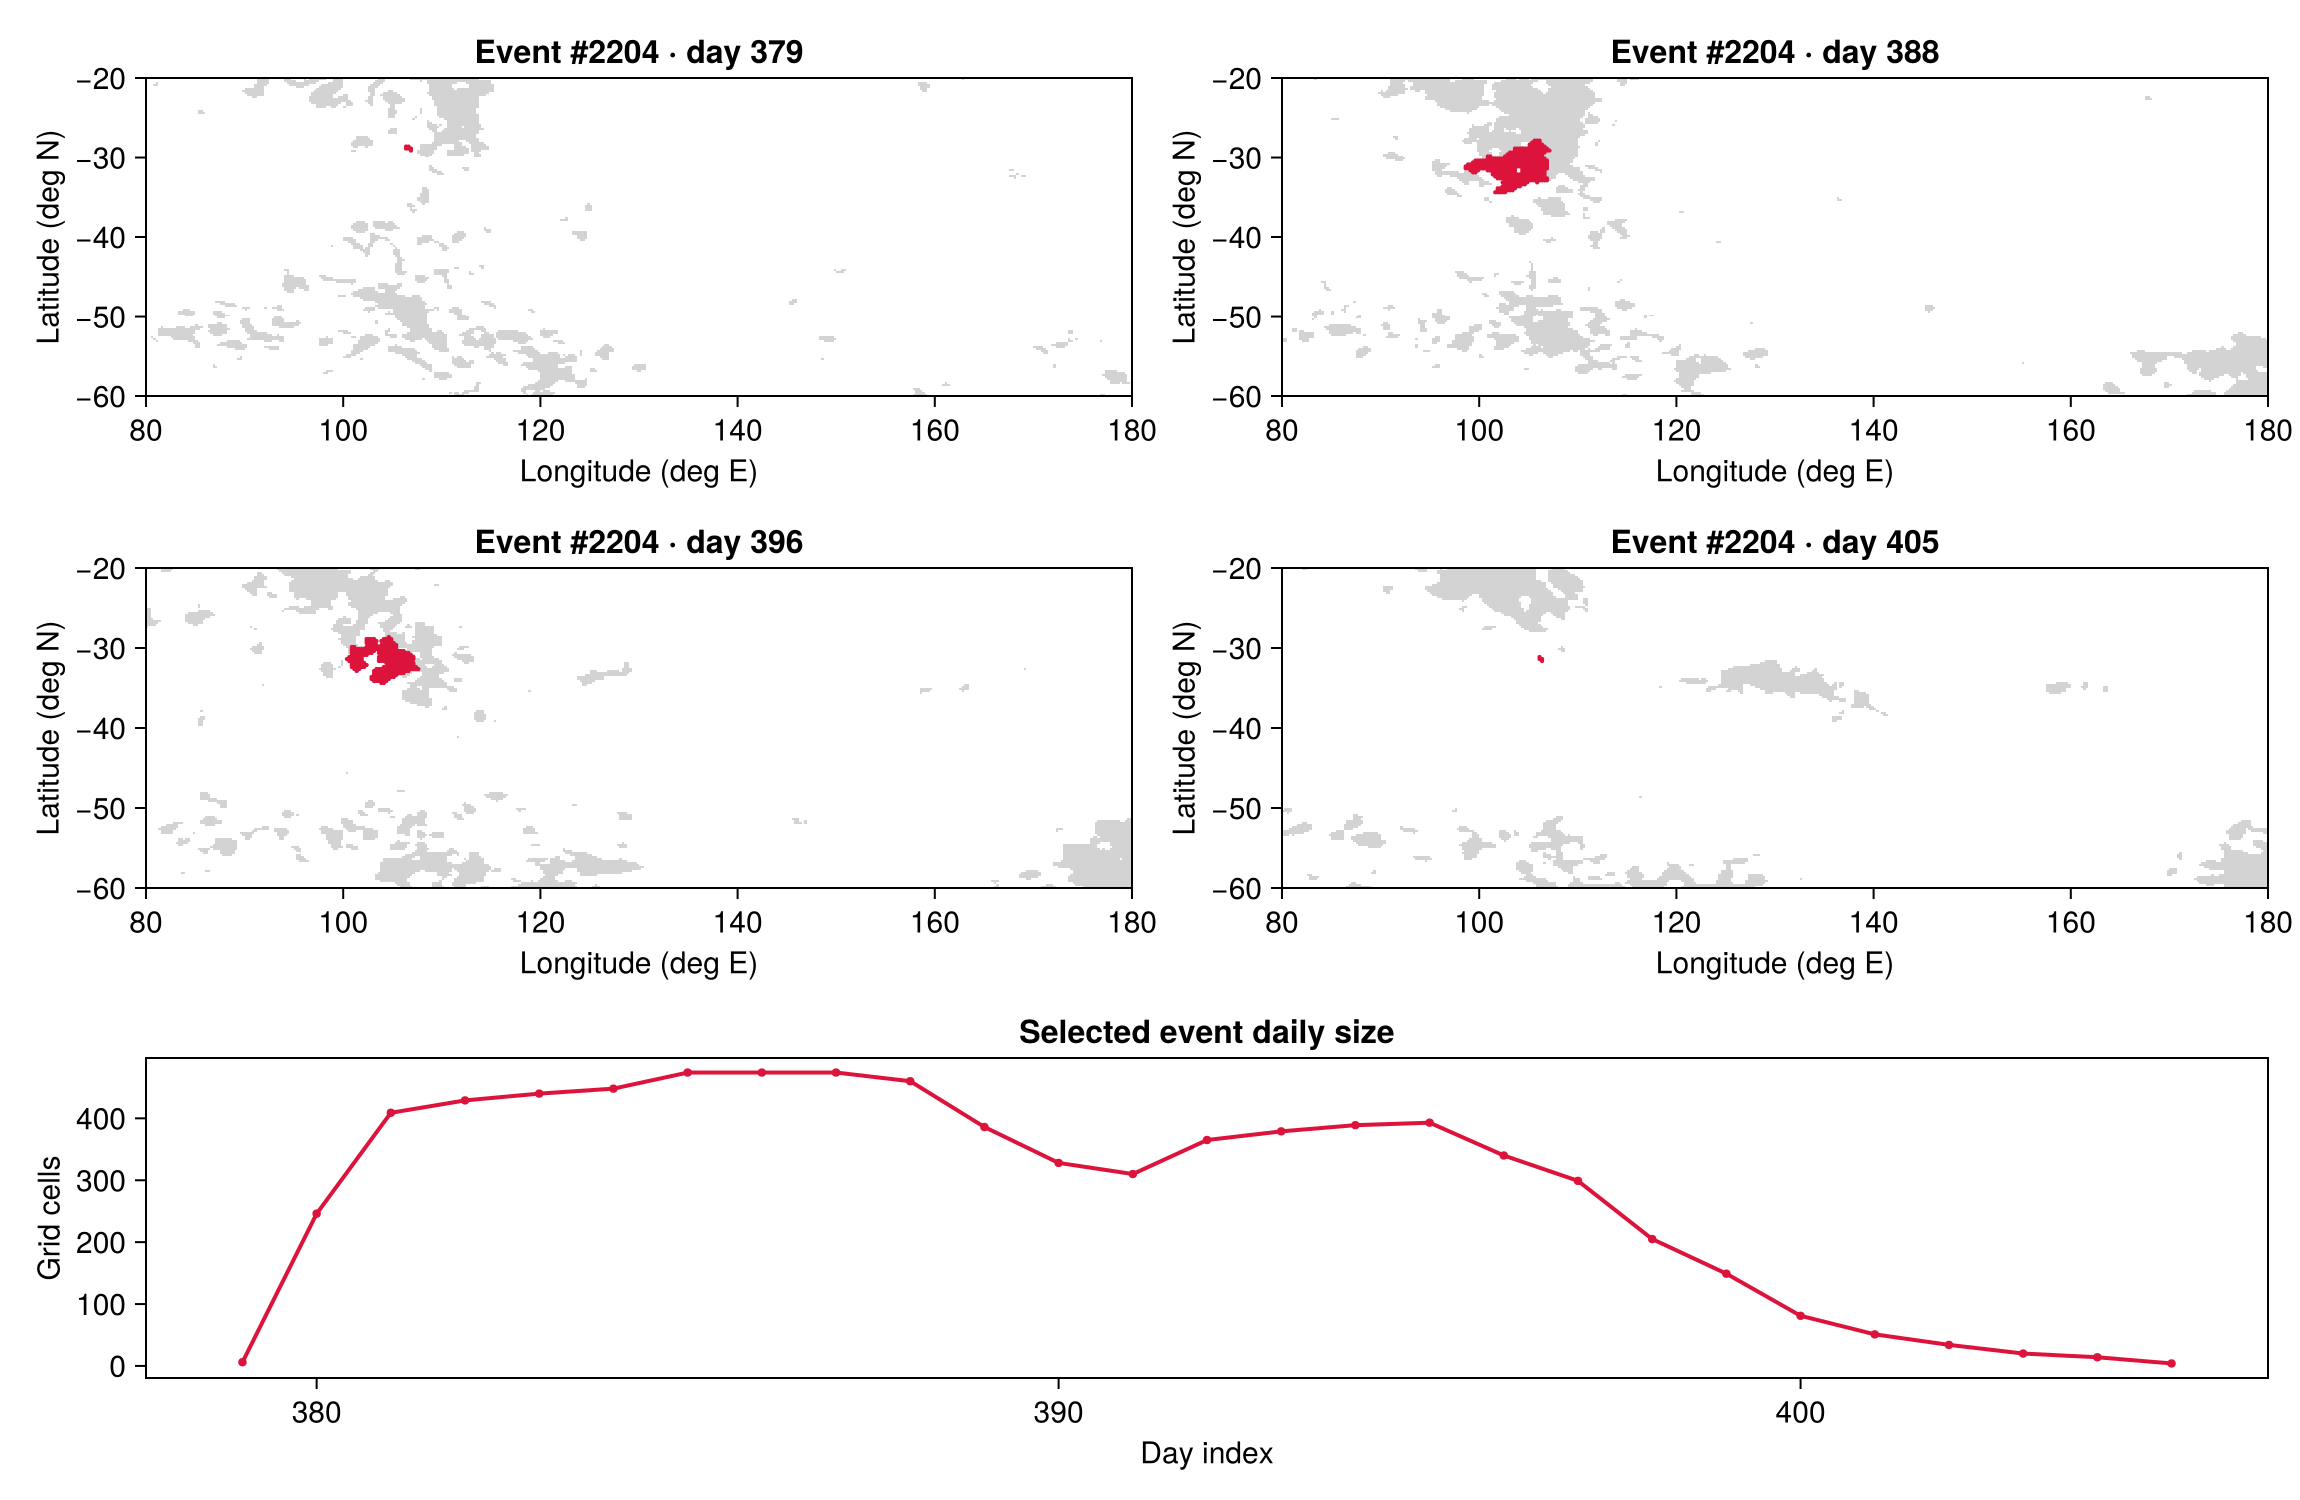

In [6]:
candidates=findall(t->7<=length(t.day)<=30,tracks)
event_id=candidates[argmax(coverage[candidates])]
event=tracks[event_id]
println("Event #",event_id," | days ",first(event.day),"–",last(event.day),
    " | cell-days ",coverage[event_id]," | split days ",event.split_day)
chosen=unique(round.(Int,range(1,length(event.day);length=4)))
fig=Figure(size=(1150,750))
for (p,j) in enumerate(chosen)
    ax=Axis(fig[cld(p,2),mod1(p,2)],title="Event #$event_id · day $(event.day[j])",
        xlabel="Longitude (deg E)",ylabel="Latitude (deg N)")
    heatmap!(ax,lon,lat,Float32.(mask[:,:,event.day[j]]);colormap=[:white,:lightgray],colorrange=(0,1))
    scatter!(ax,lon[Int.(event.xloc[j])],lat[Int.(event.yloc[j])];color=:crimson,markersize=3)
end
ax=Axis(fig[3,1:2],title="Selected event daily size",xlabel="Day index",ylabel="Grid cells")
lines!(ax,event.day,length.(event.xloc);color=:crimson,linewidth=2)
scatter!(ax,event.day,length.(event.xloc);color=:crimson,markersize=6)
emit_figure(fig,"02_real_event_evolution")

## Optional: strict comparison with the full MATLAB reference
The large MATLAB output remains in this workspace's `validation/results` and is not distributed with the small Git fixtures. If absent, this step explicitly reports NOT RUN. Equal event counts alone do not establish agreement.

In [7]:
reference=joinpath(ROOT,"validation","results","matlab_real_positive.mat")
if isfile(reference)
    expected=overlap_from_mat(matread(reference)["tracks"])
    @test strict_overlap_equal(tracks,expected)
    @test partition_equal(tracks,expected,size(mask))
    println("Full MATLAB reference: all seven fields and memberships exactly match.")
else
    println("NOT RUN: full MATLAB reference unavailable; see docs/validation_report.md for the recorded run.")
end

Full MATLAB reference: all seven fields and memberships exactly match.
